In [1]:
import csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import factorial
from scipy.interpolate import RBFInterpolator
from scipy.optimize import root_scalar
from collections import defaultdict


In [2]:
# Apply Savitzky-Golay filter
from scipy.signal import savgol_filter
window_length = 11  # Must be odd
polyorder = 3

## Read the processed dataframes

In [3]:
received_results_df = pd.read_feather("received_results_df.feather")
investigate_df = pd.read_feather("investigate_df.feather")

In [4]:
import heapq
import numpy as np

def process_group(group):
    """
    Process one run group (DataFrame) and compute the state i for each request.
    Returns a list of tuples: (n, alpha, i, client_measured_time, server_processing_time_measured).
    """
    # Extract n and alpha from the group (they are constant within a group)
    n = group['active_servers_num'].iloc[0]
    alpha = group['alpha'].iloc[0]
    
    # Sort by request_id to ensure chronological order
    group = group.sort_values('request_id').reset_index(drop=True)
    
    # Convert relevant columns to numpy arrays for speed
    time_until_next = group['time_untill_next_client'].values
    client_measured = group['client_measured_time'].values
    server_processing = group['server_processing_time_measured'].values
    
    # Compute arrival times: first at t=0, then cumulative sum of inter-arrival times
    arrival_times = np.zeros(len(group))
    if len(group) > 1:
        arrival_times[1:] = np.cumsum(time_until_next[:-1])
    
    # Departure times = arrival + total round‑trip time
    departure_times = arrival_times + client_measured
    
    # Min‑heap to track active departures (maintains earliest departure at top)
    heap = []
    states = []
    
    for k, t_arr in enumerate(arrival_times):
        # Remove all departures that happened before or at this arrival
        while heap and heap[0] <= t_arr:
            heapq.heappop(heap)
        
        # Number of active previous requests = heap size
        active_before = len(heap)
        i = active_before + 1   # total in system after this request joins
        
        # Store the state information
        states.append((n, alpha, i, client_measured[k], server_processing[k]))
        
        # Push current departure time into the heap for future arrivals
        heapq.heappush(heap, departure_times[k])
    
    return states

In [5]:
all_states = []
for (alpha, n, run), group in received_results_df.groupby(['alpha', 'active_servers_num', 'run_id']):
    all_states.extend(process_group(group))

# Convert to DataFrame
state_df = pd.DataFrame(all_states, columns=['n', 'alpha', 'i', 'client_measured_time', 'server_processing_time_measured'])

In [6]:
all_states[0]

(np.int64(1), np.float64(0.0), 1, np.float64(1.162), np.float64(1.156532))

In [7]:
# --- Aggregate by (n, alpha, i) to get mean times and counts ---
agg = state_df.groupby(['n', 'alpha', 'i']).agg(
    T_emp=('client_measured_time', 'mean'),
    S_emp=('server_processing_time_measured', 'mean'),
    count=('client_measured_time', 'size')
).reset_index()

In [8]:
agg.head()

,n,alpha,i,T_emp,S_emp,count
0,1,0.0,1,2.1585,2.152518,2
1,1,0.0,2,3.2975,1.505104,2
2,1,0.0,3,4.3870,1.150848,2
3,1,0.0,4,3.9650,0.816996,3
4,1,0.0,5,5.3725,0.567835,2


<Axes: >

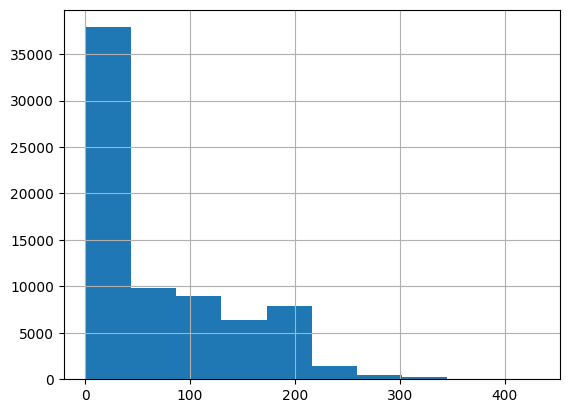

In [9]:
agg['count'].hist()

In [10]:
# --- Calculate effective μ and pure μ ---
results = []

for _, row in agg.iterrows():
    n = int(row['n'])
    alpha = row['alpha']
    i = int(row['i'])
    T_emp = row['T_emp']
    S_emp = row['S_emp']
    count = row['count']
    
    # Pure service rate (from server processing time)
    mu_pure = 1.0 / S_emp if S_emp > 0 else np.nan
    
    # Effective service rate (from total round time)
    if i <= n:
        # No queue: T_emp = 1 / mu_eff
        mu_eff = 1.0 / T_emp if T_emp > 0 else np.nan
    else:
        # Queue: T_emp = i / (n * mu_eff)   (corrected formula)
        mu_eff = i / (n * T_emp) if T_emp > 0 else np.nan
    
    service_time_eff = 1.0 / mu_eff if not np.isnan(mu_eff) else np.nan
    service_time_pure = 1.0 / mu_pure if not np.isnan(mu_pure) else np.nan
    overhead = service_time_eff - service_time_pure if not np.isnan(service_time_eff) and not np.isnan(service_time_pure) else np.nan
    
    results.append({
        'n': n,
        'alpha': alpha,
        'i': i,
        'count': count,
        'mu_pure': mu_pure,
        'mu_eff': mu_eff,
        'service_time_pure (s)': service_time_pure,
        'service_time_eff (s)': service_time_eff,
        'overhead_per_request (s)': overhead
    })

results_df = pd.DataFrame(results)

# --- Output the dictionary mu_d for your model ---
mu_d = {}
for _, row in results_df.iterrows():
    key = (row['n'], row['alpha'], row['i'])
    mu_d[key] = row['mu_eff']


In [11]:
results_df.head()

,n,alpha,i,count,mu_pure,mu_eff,service_time_pure (s),service_time_eff (s),overhead_per_request (s)
0,1,0.0,1,2.0,0.464572,0.463285,2.152518,2.158500,0.005982
1,1,0.0,2,2.0,0.664406,0.606520,1.505104,1.648750,0.143646
2,1,0.0,3,2.0,0.868924,0.683839,1.150848,1.462333,0.311485
3,1,0.0,4,3.0,1.223997,1.008827,0.816996,0.991250,0.174254
4,1,0.0,5,2.0,1.761077,0.930665,0.567835,1.074500,0.506665


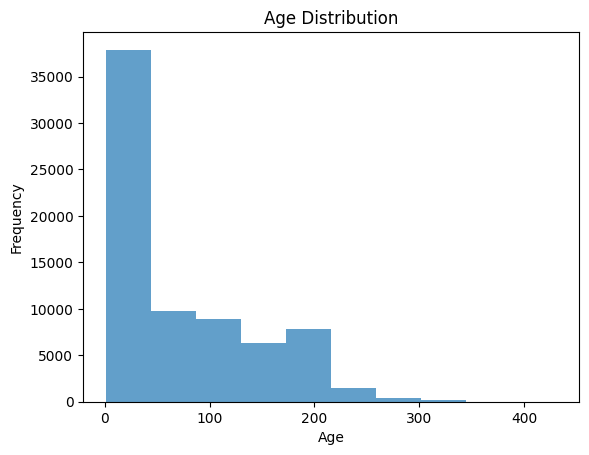

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

results_df['count'].plot(kind='hist', alpha=0.7)

# Step 3: Show the plot
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()


<Axes: ylabel='Frequency'>

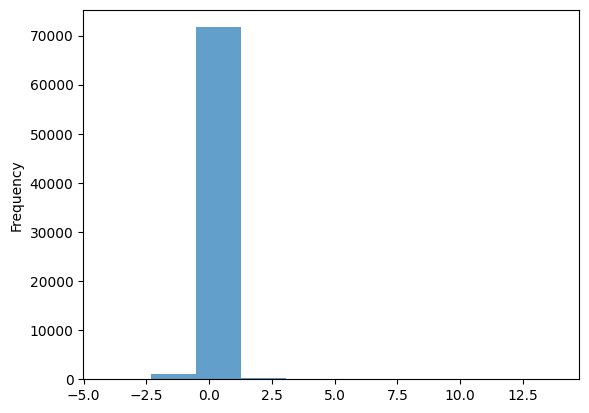

In [13]:
results_df["overhead_per_request (s)"].plot(kind='hist', alpha=0.7)

In [14]:
results_df[results_df["overhead_per_request (s)"] < 0]

,n,alpha,i,count,mu_pure,mu_eff,service_time_pure (s),service_time_eff (s),overhead_per_request (s)
6,1,0.0,7,3.0,0.523984,0.999096,1.908455,1.000905,-0.907550
8,1,0.0,9,2.0,0.581139,0.942902,1.720760,1.060556,-0.660204
9,1,0.0,10,2.0,0.511817,0.896218,1.953823,1.115800,-0.838023
10,1,0.0,11,2.0,0.631736,0.873952,1.582939,1.144227,-0.438711
11,1,0.0,12,5.0,0.593103,0.788063,1.686047,1.268933,-0.417114
...,...,...,...,...,...,...,...,...,...
9419,13,1.0,16,1.0,1.206377,1.465201,0.828928,0.682500,-0.146428
9450,14,0.1,18,1.0,0.735026,0.941915,1.360497,1.061667,-0.298830
9956,17,0.5,18,4.0,0.642122,0.678081,1.557336,1.474750,-0.082586
9961,17,0.5,23,1.0,0.786236,1.060299,1.271883,0.943130,-0.328753


In [15]:
results_df[results_df["overhead_per_request (s)"] > 0]

,n,alpha,i,count,mu_pure,mu_eff,service_time_pure (s),service_time_eff (s),overhead_per_request (s)
0,1,0.0,1,2.0,0.464572,0.463285,2.152518,2.158500,0.005982
1,1,0.0,2,2.0,0.664406,0.606520,1.505104,1.648750,0.143646
2,1,0.0,3,2.0,0.868924,0.683839,1.150848,1.462333,0.311485
3,1,0.0,4,3.0,1.223997,1.008827,0.816996,0.991250,0.174254
4,1,0.0,5,2.0,1.761077,0.930665,0.567835,1.074500,0.506665
...,...,...,...,...,...,...,...,...,...
73018,1000,1.0,8,37.0,0.630337,0.628034,1.586453,1.592270,0.005817
73019,1000,1.0,9,25.0,0.728445,0.720171,1.372787,1.388560,0.015773
73020,1000,1.0,10,15.0,0.836433,0.661230,1.195552,1.512333,0.316781
73021,1000,1.0,11,6.0,0.664995,0.662398,1.503772,1.509667,0.005895


In [16]:
len(results_df)

73023

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import factorial

# ------------------------------------------------------------
# 1. Compute the theoretical T from your formulas
# ------------------------------------------------------------

def compute_T(n, lam, alpha, mu_d):
    """
    Compute the mean response time T for given n, λ, α.
    mu_d is a dict: key = (n, alpha, i) -> μ_eff.
    We assume that for this (n, alpha) we have μ for all i=1..n.
    """
    # Check that we have all needed rates
    for i in range(1, n+1):
        if (n, alpha, i) not in mu_d:
            raise ValueError(f"Missing μ for n={n}, alpha={alpha}, i={i}")
    
    # Extract rates for i=1..n
    mu_vals = [mu_d[(n, alpha, i)] for i in range(1, n+1)]
    
    # Compute products for the sums: prod_{j=1}^{i} μ(j)
    prod_terms = [1.0]
    for i in range(1, n+1):
        prod_terms.append(prod_terms[-1] * mu_vals[i-1])
    # prod_terms[i] = Π_{j=1}^{i} μ(j)
    
    # 1. Compute p0
    # Sum over i=1..n: λ^i / (i! * prod_terms[i])
    sum1 = 0.0
    for i in range(1, n+1):
        sum1 += (lam**i) / (factorial(i) * prod_terms[i])
    
    # Term for i=n+1: λ^(n+1) / (n! * prod_terms[n] * (n*μ(n) - λ))
    mu_n = mu_vals[n-1]  # μ(n,α,n)
    denom = factorial(n) * prod_terms[n] * (n * mu_n - lam)
    if denom <= 0:
        raise ValueError(f"Unstable system for n={n}, alpha={alpha}: n*μ_n - λ = {n*mu_n - lam} <= 0")
    term_n1 = (lam**(n+1)) / denom
    p0 = 1.0 / (1.0 + sum1 + term_n1)
    
    # 2. Compute L (mean number in system) using the second part of your formula
    # First sum: Σ_{k=1}^{n} k * λ^k / (k! * prod_terms[k]) * p0
    sum_L1 = 0.0
    for k in range(1, n+1):
        sum_L1 += k * (lam**k) / (factorial(k) * prod_terms[k])
    
    # Second term: λ^(n+1) / ((n-1)! * prod_terms[n] * (n*μ_n - λ)) * (1 + μ_n/(n*μ_n - λ)) * p0
    term_L2_num = lam**(n+1)
    term_L2_den = factorial(n-1) * prod_terms[n] * (n * mu_n - lam)
    term_L2 = (term_L2_num / term_L2_den) * (1.0 + mu_n / (n * mu_n - lam))
    
    L = (sum_L1 + term_L2) * p0
    
    # 3. T = L / λ
    T = L / lam
    return T

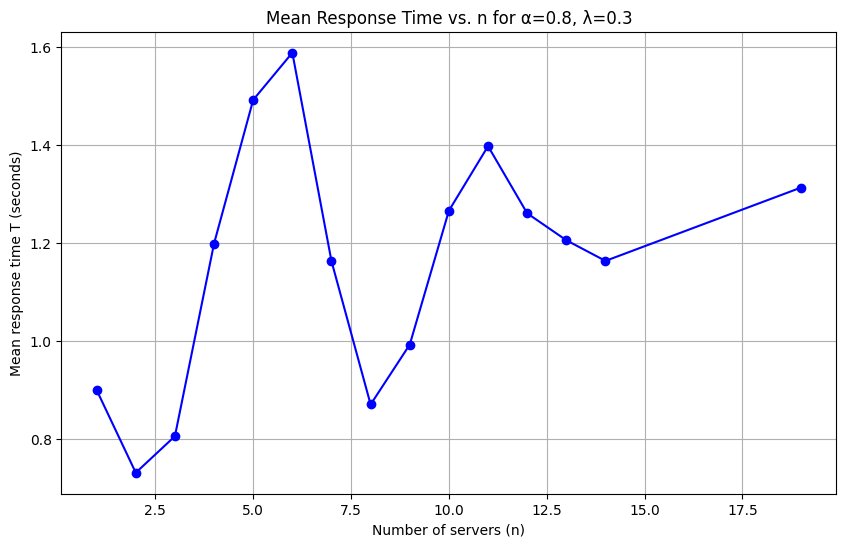

In [18]:
# ------------------------------------------------------------
# 2. Prepare the data for plotting (α = 0.4)
# ------------------------------------------------------------

# Assume 'mu_d' is already computed as described in previous steps.
# For demonstration, we'll create a dummy mu_d; replace with your actual dict.
# (In your code, you will have mu_d from the prior processing.)

# Example dummy data (replace with real data):
# mu_d = { (n, alpha, i): value_for_mu_eff }

# We filter for alpha = 0.4
alpha_target = 0.8
lam = 0.3  # constant from your experiments

# Collect all n values for which we have complete information
n_values = set()
for (n, alpha, i) in mu_d.keys():
    if alpha == alpha_target:
        n_values.add(np.int64(n))

# For each n, check if we have all i=1..n
valid_n = []
missing_n = set()
for n in n_values:
    try:
        T = compute_T(n, lam, alpha_target, mu_d)
        valid_n.append((n, T))
    except ValueError:
        # Skip n if data missing or unstable
        missing_n.add(n)
        pass

# Sort by n
valid_n.sort(key=lambda x: x[0])
if not valid_n:
    print(f"No valid data for alpha={alpha_target}. Check mu_d content.")
else:
    n_vals, T_vals = zip(*valid_n)
    
    # ------------------------------------------------------------
    # 3. Plot
    # ------------------------------------------------------------
    plt.figure(figsize=(10, 6))
    plt.plot(n_vals, T_vals, marker='o', linestyle='-', color='b')
    plt.xlabel('Number of servers (n)')
    plt.ylabel('Mean response time T (seconds)')
    plt.title(f'Mean Response Time vs. n for α={alpha_target}, λ={lam}')
    plt.grid(True)
    plt.show()

In [19]:
def compute_T(n, lam, alpha, mu_d, extrapolate_mu=None):
    """
    Compute the mean response time T for an M/M/n queue with state-dependent
    service rates μ(n, α, i). This function implements your exact formulas
    using numerically stable recurrences.

    Parameters
    ----------
    n : int
        Number of servers.
    lam : float
        Arrival rate (λ).
    alpha : float
        The alpha parameter used to index mu_d.
    mu_d : dict
        Dictionary with keys (n, alpha, i) mapping to the effective service
        rate μ(n, α, i). Must contain rates for i=1..n unless extrapolate_mu
        is provided.
    extrapolate_mu : callable, optional
        Function with signature extrapolate_mu(n, alpha, i) -> float.
        If provided, it is called when (n, alpha, i) is missing from mu_d.
        This allows extrapolating to unseen n or i values.

    Returns
    -------
    T : float
        Mean response time (sojourn time) in the system.

    Raises
    ------
    ValueError
        If a required μ is missing and no extrapolator is provided, or if the
        system is unstable (n*μ(n,α,n) - λ ≤ 0).
    """
    
    # Helper to fetch μ(i), with fallback
    def get_mu(i):
        key = (n, alpha, i)
        if key in mu_d:
            return mu_d[key]
        elif extrapolate_mu is not None:
            return extrapolate_mu(n, alpha, i)
        else:
            raise ValueError(f"Missing μ for n={n}, alpha={alpha}, i={i}")
    
    # Retrieve all required μ_i for i=1..n
    mu_vals = [get_mu(i) for i in range(1, n+1)]
    
    # ------------------------------------------------------------------
    # 1.  Compute A_k = λ^k / ( k! * Π_{j=1}^k μ_j )  for k=0..n
    #     using recurrence: A_0 = 1, A_k = A_{k-1} * λ / (k * μ_k)
    # ------------------------------------------------------------------
    A = 1.0           # A_0
    sum1 = 0.0        # Σ_{k=1}^{n} A_k
    sum_L1 = 0.0      # Σ_{k=1}^{n} k * A_k   (needed for L)
    
    for k in range(1, n+1):
        mu_k = mu_vals[k-1]
        A = A * lam / (k * mu_k)   # now A = A_k
        sum1 += A
        sum_L1 += k * A
    
    # After the loop, A == A_n
    A_n = A
    mu_n = mu_vals[n-1]   # μ(n, α, n)
    
    # ------------------------------------------------------------------
    # 2.  Stability condition: n * μ_n - λ must be > 0
    # ------------------------------------------------------------------
    denom = n * mu_n - lam
    if denom <= 0:
        raise ValueError(
            f"Unstable system for n={n}, α={alpha}: "
            f"n·μ_n - λ = {denom} ≤ 0. Increase servers or reduce load."
        )
    
    # ------------------------------------------------------------------
    # 3.  Compute p0 using the recurrence-based expressions
    #     term for k=n+1:  λ^(n+1) / ( n! * prod_n * (n μ_n - λ) )
    #     But λ^(n+1)/(n!*prod_n) = A_n * λ, so:
    # ------------------------------------------------------------------
    term_n1 = A_n * lam / denom
    p0 = 1.0 / (1.0 + sum1 + term_n1)
    
    # ------------------------------------------------------------------
    # 4.  Compute L (mean number in system)
    #     L = [ Σ_{k=1}^n k A_k +  T_extra ] * p0
    #     where T_extra =  λ^(n+1) / ((n-1)! prod_n) *
    #                      (1 + μ_n/(n μ_n - λ)) / (n μ_n - λ)
    #
    #     But λ^(n+1) / ((n-1)! prod_n) = n * λ * A_n
    # ------------------------------------------------------------------
    factor = n * lam * A_n / denom
    term_L2 = factor * (1.0 + mu_n / denom)
    
    L = (sum_L1 + term_L2) * p0
    
    # ------------------------------------------------------------------
    # 5.  Little's Law: T = L / λ
    # ------------------------------------------------------------------
    T = L / lam
    return T

In [20]:
import numpy as np
from collections import defaultdict

def build_state_only_extrapolator(mu_d):
    """
    Aggregates μ across all observed n for each (alpha, i).
    For any requested n, returns the average μ for that (alpha, i).
    """
    state_rates = defaultdict(list)
    for (n, alpha, i), mu in mu_d.items():
        state_rates[(alpha, i)].append(mu)
    
    # Compute mean μ per state
    avg_state_rates = {}
    for (alpha, i), rates in state_rates.items():
        avg_state_rates[(alpha, i)] = np.mean(rates)
    
    def extrapolate(n, alpha, i):
        key = (alpha, i)
        if key in avg_state_rates:
            return avg_state_rates[key]
        else:
            # Fallback: if this state was never observed,
            # we use the global average of all observed rates.
            return np.mean(list(mu_d.values()))
    
    return extrapolate

In [21]:
def build_saturation_extrapolator(mu_d):
    """
    For each (alpha, i), remembers the μ observed at the largest n.
    For any requested n larger than that, returns that same μ.
    """
    max_n_rates = {}
    for (n, alpha, i), mu in mu_d.items():
        key = (alpha, i)
        if key not in max_n_rates or n > max_n_rates[key][0]:
            max_n_rates[key] = (n, mu)
    
    def extrapolate(n, alpha, i):
        key = (alpha, i)
        if key in max_n_rates:
            return max_n_rates[key][1]
        else:
            # Fallback: global mean
            return np.mean(list(mu_d.values()))
    
    return extrapolate

In [22]:
from scipy import stats  # optional, or use np.polyfit

def build_linear_extrapolator(mu_d, clamp_max=None):
    """
    For each (alpha, i), fits μ = a * n + b using observed data.
    Predicts μ for any n, then clamps it to clamp_max if given.
    """
    # Group points by (alpha, i)
    grouped = defaultdict(list)
    for (n, alpha, i), mu in mu_d.items():
        grouped[(alpha, i)].append((n, mu))
    
    models = {}
    global_mean = np.mean(list(mu_d.values()))
    
    for (alpha, i), points in grouped.items():
        points.sort()  # sort by n
        ns = np.array([p[0] for p in points])
        mus = np.array([p[1] for p in points])
        
        if len(points) >= 2:
            # Linear fit
            slope, intercept = np.polyfit(ns, mus, 1)
            models[(alpha, i)] = (slope, intercept)
        else:
            # Only one point: use it as a constant
            models[(alpha, i)] = (0.0, points[0][1])
    
    if clamp_max is None:
        # Default clamp to the maximum μ ever observed (safe upper bound)
        clamp_max = max(mu_d.values())
    
    def extrapolate(n, alpha, i):
        key = (alpha, i)
        if key in models:
            slope, intercept = models[key]
            val = slope * n + intercept
            # Clamp to avoid negative or crazy large values
            return max(0.1, min(val, clamp_max))
        else:
            return global_mean
    
    return extrapolate

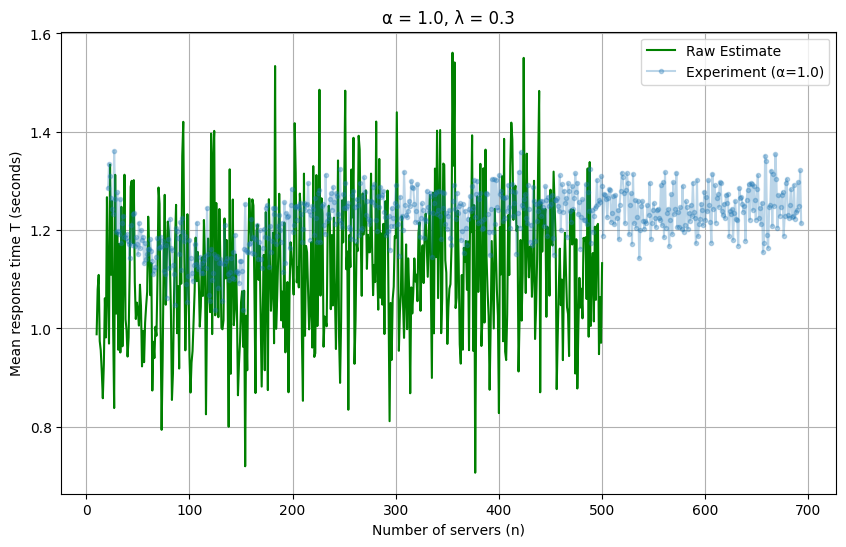

In [23]:
# 1. Build your extrapolator (choose one)
extrapolate = build_state_only_extrapolator(mu_d)   # or build_saturation_extrapolator, etc.

# 2. Compute T for various n
import matplotlib.pyplot as plt

lam = 0.3
alpha_target = 1.0
n_range = range(10, 501)
T_values = []

for n in n_range:
    try:
        T = compute_T(n, lam, alpha_target, mu_d, extrapolate_mu=extrapolate)
        T_values.append(T)
    except ValueError as e:
        print(f"Skipping n={n}: {e}")
        T_values.append(np.nan)

alpha_df = investigate_df[investigate_df['alpha'] == alpha_target]
if alpha_df.empty:
    raise ValueError(f"No experimental data for alpha={alpha_target}")

# 3. Plot
plt.figure(figsize=(10,6))
plt.plot(n_range, T_values, '-', color='green', label="Raw Estimate")
# plt.plot(n_range, T_values, '-', color='orange', label="Smooth")

x_exp = alpha_df['active_servers_num'].values
y_exp_raw = alpha_df['client_measured_time'].values
plt.plot(x_exp, y_exp_raw, 'o-', label=f'Experiment (α={alpha_target})',  alpha=0.3, markersize=3)

plt.xlabel('Number of servers (n)')
plt.ylabel('Mean response time T (seconds)')
plt.title(f'α = {alpha_target}, λ = {lam}')
plt.grid(True)
plt.legend()
plt.show()